In [ ]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

from src.utils import (
    build_metabric_pipeline,
    build_preprocessor,
    count_feature_categories,
    load_metabric_data,
)

In [2]:
# Load dataset
_, df = load_metabric_data()

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


In [3]:
X, y, _, _ = build_metabric_pipeline(df)

# Inspect feature groups
counts, clinical_cols, mrna_cols, mutation_cols = count_feature_categories(X.columns)
print("\nFeature distribution:", counts)


Applying one-hot encoding to categorical columns: 
cancer_type_detailed               5 levels
er_status_measured_by_ihc          2 levels
her2_status_measured_by_snp6       4 levels
tumor_other_histologic_subtype     6 levels
inferred_menopausal_state          2 levels
integrative_cluster               11 levels
primary_tumor_laterality           2 levels
oncotree_code                      5 levels
3-gene_classifier_subtype          3 levels
dtype: str

---------


New columns after one-hot encoding:
3-gene_classifier_subtype_ER+/HER2- Low Prolif
3-gene_classifier_subtype_HER2+
cancer_type_detailed_Breast Invasive Ductal Carcinoma
cancer_type_detailed_Breast Invasive Lobular Carcinoma
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma
er_status_measured_by_ihc_Positve
her2_status_measured_by_snp6_LOSS
her2_status_measured_by_snp6_NEUTRAL
her2_status_measured_by_snp6_UNDEF
inferred_menopausal_state_Pre
integrati

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y
)

In [5]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 543 entries, 1003 to 306
Columns: 705 entries, age_at_diagnosis to 3-gene_classifier_subtype_HER2+
dtypes: float64(498), int64(207)
memory usage: 2.9 MB


In [6]:
# Build preprocessing pipeline
preprocessor = build_preprocessor(X)
preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('signature', ...), ('smart_imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [7]:
# Learn and Apply transformations
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [8]:
X_train_transformed.shape

(543, 706)

In [9]:
correct_columns = preprocessor.named_steps['col_transform'].get_feature_names_out()

clean_columns = [col.split('__')[-1] for col in correct_columns]

X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=clean_columns,
    index=X_train.index
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=clean_columns,
    index=X_test.index
)

In [10]:
print("Final shape:", X_train_transformed.shape)
X_train_transformed.head()

Final shape: (543, 706)


,age_at_diagnosis,cellularity,cohort,neoplasm_histologic_grade,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,tumor_size,tumor_stage,brca1,...,integrative_cluster_7,integrative_cluster_8,integrative_cluster_9,primary_tumor_laterality_Right,oncotree_code_IDC,oncotree_code_ILC,oncotree_code_IMMC,oncotree_code_MDLC,3-gene_classifier_subtype_ER+/HER2- Low Prolif,3-gene_classifier_subtype_HER2+
1003,1.233557,0.964813,0.362207,-0.057436,-0.483154,-0.178616,-0.520578,-0.139852,0.448223,0.175321,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1360,1.833490,0.964813,0.362207,-0.057436,-0.483154,-0.514217,-0.524252,-0.306639,-1.163599,0.670449,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.594128,0.964813,-1.348040,1.427701,-0.483154,-1.185419,0.375805,-1.140574,-1.163599,-1.521080,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1072,-0.494251,-0.622743,0.362207,-0.057436,-0.483154,1.499388,-0.515068,0.110328,0.448223,0.726711,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1641,1.763898,-0.622743,2.072454,-0.057436,-0.483154,-0.514217,-0.524252,-0.306639,-1.163599,0.225034,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


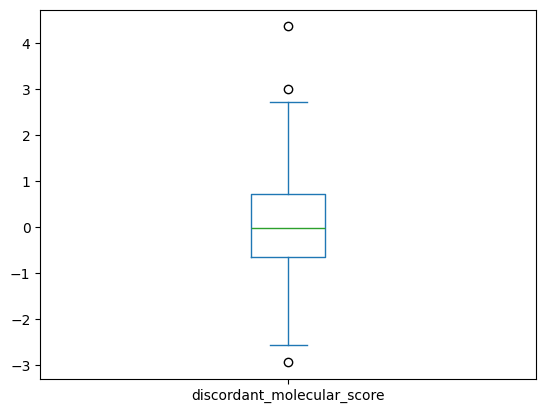

In [15]:
X_train_transformed['discordant_molecular_score'].plot(kind='box');

In [12]:
X_train_transformed.info()

<class 'pandas.DataFrame'>
Index: 543 entries, 1003 to 306
Columns: 706 entries, age_at_diagnosis to 3-gene_classifier_subtype_HER2+
dtypes: float64(706)
memory usage: 2.9 MB


In [13]:
'target_mortality' in X_train_transformed.columns

False

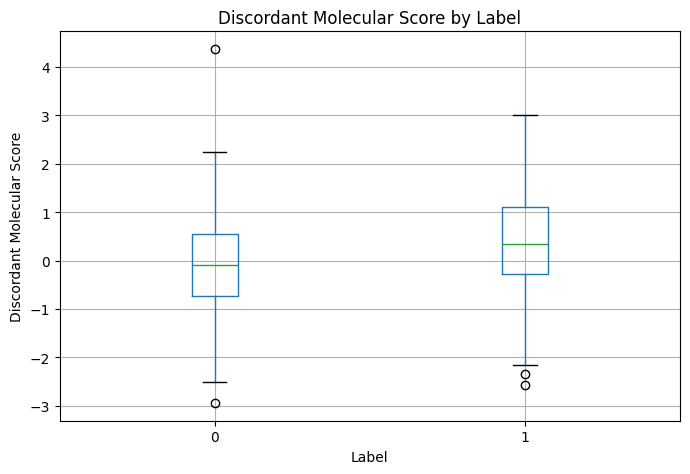

In [ ]:
pd.concat([X_train_transformed, y_train.rename('target')], axis=1).boxplot(column='discordant_molecular_score', by='target', figsize=(7, 5))
plt.suptitle('')  

plt.title('Discordant Molecular Score by Label')
plt.xlabel('Label')
plt.ylabel('Discordant Molecular Score')
plt.tight_layout()
plt.show()